$E(x) =E(5,1,3,6,4) = \frac{1}{5} \cdot 5 + \frac{1}{5} \cdot1 + \frac{1}{5} \cdot3 + \frac{1}{5} \cdot6 + \frac{1}{5} \cdot4 = 1+0.2 +0.6 + 1.2 + 0.8 = 3.8$

$4.4, 3.8, 4.8, 4.0, 3.4, 4.2, 5.2$

In [1]:
sample = {5, 1, 3, 6, 4,}

In [2]:
math_est = sum(sample) / len(sample)
math_est

3.8

In [22]:
dispertion = sum((math_est - number)**2 for number in list(sample)) / len(sample)
dispertion

2.96

In [3]:
samples_me = [4.4, 3.8, 4.8, 4.0, 3.4, 4.2, 5.2,]

In [23]:
dispertion_samples_me = sum( (number - math_est)**2 for number in samples_me) / len(samples_me)
dispertion_samples_me

0.525714285714286

In [24]:
import pandas as pd
import numpy as np

In [29]:
df = pd.DataFrame(samples_me)
df.describe()

,0
count,7.000000
mean,4.257143
std,0.607885
min,3.400000
25%,3.900000
50%,4.200000
75%,4.600000
max,5.200000


In [48]:
var = (df.mean() - df)**2
var

,0
0,0.020408
1,0.208980
2,0.294694
3,0.066122
4,0.734694
5,0.003265
6,0.888980


In [ ]:
var.sum() / var.shape[0]

0    0.316735
dtype: float64

In [49]:
var.describe()

,0
count,7.000000
mean,0.316735
std,0.356635
min,0.003265
25%,0.043265
50%,0.208980
75%,0.514694
max,0.888980


In [47]:
var.sum() / (var.shape[0] - 1)

0    0.369524
dtype: float64

In [32]:
df

,0
0,4.4
1,3.8
2,4.8
3,4.0
4,3.4
5,4.2
6,5.2


In [38]:
df.shape[0]

7

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [66]:
data = pd.read_csv(r"data/boston.csv", decimal=',')

In [67]:
data.head()

,crim_rate,zn,business,river,nit_oxiden,rooms,age,dist,highways_index,tax,pup_per_teaс,lower,target
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crim_rate       506 non-null    float64
 1   zn              506 non-null    float64
 2   business        506 non-null    float64
 3   river           506 non-null    int64  
 4   nit_oxiden      506 non-null    float64
 5   rooms           506 non-null    float64
 6   age             506 non-null    float64
 7   dist            506 non-null    float64
 8   highways_index  506 non-null    int64  
 9   tax             506 non-null    int64  
 10  pup_per_teaс    506 non-null    float64
 11  lower           506 non-null    float64
 12  target          506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


**Задание 3.4**

1. Разбейте набор данных на обучающую и тестовую выборку в соотношении 70/30, при разбиении задайте параметр random_state = 13.

In [ ]:
# делим выборку на фичи и таргет
target = 'target'
y = data[target]
X = data.drop(columns=target)

In [73]:
y.describe()

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: target, dtype: float64

In [74]:
# Формируем обучающую и тестовую выборки
test_size = 0.3
random_state = 13
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=test_size, random_state=random_state)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (354, 12)
Test shape: (152, 12)


Какое получилось среднее значение медианных цен на обучающей выборке? Ответ округлите до двух знаков после точки-разделителя.

In [75]:
y_train.describe()

count    354.000000
mean      22.773164
std        9.233011
min        5.000000
25%       17.200000
50%       21.550000
75%       25.975000
max       50.000000
Name: target, dtype: float64

2. Обучите линейную регрессию с параметрами по умолчанию.

В качестве ответа введите ошибку MAE на тестовой выборке. Ответ округлите до двух знаков после точки-разделителя.



In [93]:
# 1. Создание экземпляра модели с параметрами по умолчанию
model = LinearRegression()

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# Расчет MAE
mae = mean_absolute_error(y_test, y_pred)

# Вывод результата
print(f"Средняя абсолютная ошибка (MAE): {mae}")

Средняя абсолютная ошибка (MAE): 3.7222793958561446


3. Обучите решающее дерево с параметрами по умолчанию и аргументом random_state = 13.

Можно ли, опираясь на результаты, сделать вывод, что алгоритм переобучился?

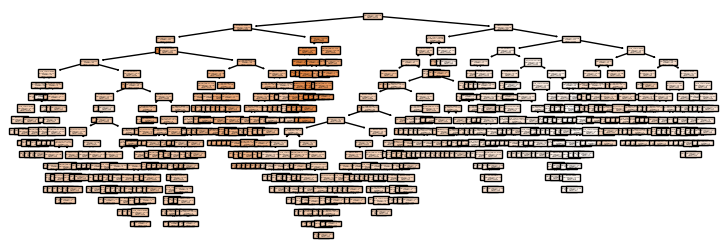

In [85]:
dt = tree.DecisionTreeRegressor(random_state=13,)
dt.fit(X_train, y_train)

fig = plt.figure(figsize=(9, 3))
tree_graph = tree.plot_tree(
    decision_tree=dt, 
    feature_names=X.columns, 
    filled=True, 
    impurity=True
);

In [87]:
from sklearn.ensemble import RandomForestRegressor
# Предположим, что X - это ваши признаки, а y - это метки классов.
# Эти данные должны быть загружены и предобработаны до начала обучения.

# Создайте список с желаемыми значениями количества деревьев
estimators = [3, 10, 100, 500]
models = []

# Обучите модель для каждого значения
for n_estimators in estimators:
    # Создайте модель случайного леса
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=13)
    # Обучите модель на ваших данных
    model.fit(X_train, y_train)
    # Добавьте обученную модель в список
    models.append(model)
    print(f"Обучена модель с {n_estimators} деревьями.")

# Теперь у вас есть список 'models' с четырьмя обученными моделями,
# готовыми для предсказания или оценки.

Обучена модель с 3 деревьями.
Обучена модель с 10 деревьями.
Обучена модель с 100 деревьями.
Обучена модель с 500 деревьями.


In [92]:
print("\n--- Результаты MAE на тестовом наборе данных ---")

# Перебор обученных моделей и вычисление MAE
for model in models:
    # Предсказание на тестовых данных
    y_pred = model.predict(X_test)
    
    # Вычисление средней абсолютной ошибки
    # MAE измеряет среднюю абсолютную разницу между истинными и предсказанными значениями
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f'(n_estimators={model.n_estimators}): MAE = {mae:.2f}')


--- Результаты MAE на тестовом наборе данных ---
(n_estimators=3): MAE = 2.93
(n_estimators=10): MAE = 2.47
(n_estimators=100): MAE = 2.26
(n_estimators=500): MAE = 2.24
